<a href="https://colab.research.google.com/github/EduardoSBorges1/grupo-x-analytica/blob/main/Transporte_Crimes.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
#importações
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score
from xgboost import XGBRegressor
import re
from collections import Counter

# **Área**

In [ ]:
# Requisição à API do ArcGIS
import requests

url = "https://services1.arcgis.com/OlP4dGNtIcnD3RYf/arcgis/rest/services/Atlas_Densidade_Demografica/FeatureServer/0/query"

params = {
    "where": "1=1",
    "outFields": "*",
    "returnGeometry": "false",
    "f": "json"
}

r = requests.get(url, params=params)
data = r.json()

df_area = pd.DataFrame([f["attributes"] for f in data["features"]])

In [ ]:
df_area

,OBJECTID_1,OBJECTID,Área,NOME,REGIAO_ADM,AREA_PLANE,CODBAIRRO,CODRA,CODBNUM,LINK,RP,Cod_RP,CODBAIRRO_,SHAPE_STAr,SHAPE_STLe,Pop,Dens_Pop,De_PopKm,Shape__Area,Shape__Length
0,1,325,1.705684e+06,Paquetá,PAQUETA,1,13,21,13,Paqueta&area=013,Centro,1.1,13,1.705685e+06,24841.426669,3361,0.001970,1970,1.705685e+06,24841.426423
1,2,326,4.056403e+06,Freguesia (Ilha),ILHA DO GOVERNADOR,3,98,20,98,Freguesia (Ilha) &area=98,Ilha do Governador,3.7,98,4.056403e+06,18303.595718,19437,0.004792,4792,4.056403e+06,18303.595691
2,3,327,9.780466e+05,Bancários,ILHA DO GOVERNADOR,3,97,20,97,Bancários &area=97,Ilha do Governador,3.7,97,9.780465e+05,7758.781282,12512,0.012793,12793,9.780466e+05,7758.781430
3,4,328,1.895742e+07,Galeão,ILHA DO GOVERNADOR,3,104,20,104,Galeão &area=104,Ilha do Governador,3.7,104,1.895742e+07,21510.059220,22971,0.001212,1212,1.895742e+07,21510.059336
4,5,329,1.672546e+06,Tauá,ILHA DO GOVERNADOR,3,101,20,101,Tauá &area=101,Ilha do Governador,3.7,101,1.672546e+06,8246.109606,29567,0.017678,17678,1.672546e+06,8246.109625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,158,485,2.983258e+05,Lapa,CENTRO,1,161,2,161,Lapa&area=161,Centro,1.1,161,2.983258e+05,3849.176575,11587,0.038840,38840,2.983258e+05,3849.176566
158,159,510,1.044451e+08,Campo Grande,CAMPO GRANDE,5,144,18,144,Campo Grande &area=144,Campo Grande,5.2,144,1.044451e+08,75083.652132,328370,0.003144,3144,1.044451e+08,75083.652220
159,160,511,3.596620e+07,Bangu,BANGU,5,141,17,141,Bangu &area=141,Bangu,5.1,141,3.596620e+07,46528.973151,220552,0.006132,6132,3.596619e+07,46528.974222
160,161,512,2.534304e+06,Gericinó,BANGU,5,160,17,160,Gericinó &area=160,Bangu,5.1,160,2.534304e+06,8828.543760,13564,0.005352,5352,2.534304e+06,8828.543749


In [ ]:
# le = LabelEncoder()

# df_area["REGIAO_ADM"] = le.fit_transform(df_area["REGIAO_ADM"])

In [ ]:
df_area['Shape__Area'] = df_area['Shape__Area'] / 1000000 # precisamos dividir essa coluna por 1.000.000 para acharmos o valor em km²

In [ ]:
df_area.sort_values(by='Shape__Area', ascending=False) # Organiza df_area em ordem decrescente

,OBJECTID_1,OBJECTID,Área,NOME,REGIAO_ADM,AREA_PLANE,CODBAIRRO,CODRA,CODBNUM,LINK,RP,Cod_RP,CODBAIRRO_,SHAPE_STAr,SHAPE_STLe,Pop,Dens_Pop,De_PopKm,Shape__Area,Shape__Length
123,124,450,1.395012e+08,Guaratiba,GUARATIBA,5,151,26,151,Guaratiba &area=151,Guaratiba,5.4,151,1.395012e+08,74738.760216,110049,0.000789,789,139.501209,74738.760260
60,61,387,1.250443e+08,Santa Cruz,SANTA CRUZ,5,149,19,149,Santa Cruz &area=149,Santa Cruz,5.3,149,1.250443e+08,65717.391333,217333,0.001738,1738,125.044295,65717.391329
158,159,510,1.044451e+08,Campo Grande,CAMPO GRANDE,5,144,18,144,Campo Grande &area=144,Campo Grande,5.2,144,1.044451e+08,75083.652132,328370,0.003144,3144,104.445148,75083.652220
133,134,460,7.579648e+07,Jacarepaguá,JACAREPAGUA,4,115,16,115,Jacarepaguá &area=115,Jacarepaguá,4.1,115,7.579648e+07,73409.706350,157326,0.002076,2076,75.796482,73409.706330
144,145,471,4.815063e+07,Barra da Tijuca,BARRA DA TIJUCA,4,128,24,128,Barra da Tijuca &area=128,Barra da Tijuca,4.2,128,4.815063e+07,47771.795858,136831,0.002842,2842,48.150630,47771.795610
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
8,9,334,4.901024e+05,Cocotá,ILHA DO GOVERNADOR,3,96,20,96,Cocotá &area=96,Ilha do Governador,3.7,96,4.901024e+05,4799.071691,4877,0.009951,9951,0.490102,4799.071715
16,17,342,3.794059e+05,Praia da Bandeira,ILHA DO GOVERNADOR,3,95,20,95,Praia da Bandeira &area=95,Ilha do Governador,3.7,95,3.794059e+05,3423.222105,5948,0.015677,15677,0.379406,3423.222171
98,99,425,3.638176e+05,Saúde,PORTUARIA,1,1,1,1,Saúde &area=1,Centro,1.1,1,3.638176e+05,2646.216986,2749,0.007556,7556,0.363818,2646.216963
157,158,485,2.983258e+05,Lapa,CENTRO,1,161,2,161,Lapa&area=161,Centro,1.1,161,2.983258e+05,3849.176575,11587,0.038840,38840,0.298326,3849.176566


In [ ]:
# padronização
df_area['NOME'] = df_area['NOME'].str.lower()
df_area['NOME'] = df_area['NOME'].str.strip()
df_area

,OBJECTID_1,OBJECTID,Área,NOME,REGIAO_ADM,AREA_PLANE,CODBAIRRO,CODRA,CODBNUM,LINK,RP,Cod_RP,CODBAIRRO_,SHAPE_STAr,SHAPE_STLe,Pop,Dens_Pop,De_PopKm,Shape__Area,Shape__Length
0,1,325,1.705684e+06,paquetá,PAQUETA,1,13,21,13,Paqueta&area=013,Centro,1.1,13,1.705685e+06,24841.426669,3361,0.001970,1970,1.705685,24841.426423
1,2,326,4.056403e+06,freguesia (ilha),ILHA DO GOVERNADOR,3,98,20,98,Freguesia (Ilha) &area=98,Ilha do Governador,3.7,98,4.056403e+06,18303.595718,19437,0.004792,4792,4.056403,18303.595691
2,3,327,9.780466e+05,bancários,ILHA DO GOVERNADOR,3,97,20,97,Bancários &area=97,Ilha do Governador,3.7,97,9.780465e+05,7758.781282,12512,0.012793,12793,0.978047,7758.781430
3,4,328,1.895742e+07,galeão,ILHA DO GOVERNADOR,3,104,20,104,Galeão &area=104,Ilha do Governador,3.7,104,1.895742e+07,21510.059220,22971,0.001212,1212,18.957422,21510.059336
4,5,329,1.672546e+06,tauá,ILHA DO GOVERNADOR,3,101,20,101,Tauá &area=101,Ilha do Governador,3.7,101,1.672546e+06,8246.109606,29567,0.017678,17678,1.672546,8246.109625
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
157,158,485,2.983258e+05,lapa,CENTRO,1,161,2,161,Lapa&area=161,Centro,1.1,161,2.983258e+05,3849.176575,11587,0.038840,38840,0.298326,3849.176566
158,159,510,1.044451e+08,campo grande,CAMPO GRANDE,5,144,18,144,Campo Grande &area=144,Campo Grande,5.2,144,1.044451e+08,75083.652132,328370,0.003144,3144,104.445148,75083.652220
159,160,511,3.596620e+07,bangu,BANGU,5,141,17,141,Bangu &area=141,Bangu,5.1,141,3.596620e+07,46528.973151,220552,0.006132,6132,35.966194,46528.974222
160,161,512,2.534304e+06,gericinó,BANGU,5,160,17,160,Gericinó &area=160,Bangu,5.1,160,2.534304e+06,8828.543760,13564,0.005352,5352,2.534304,8828.543749


In [ ]:
zonas = pd.read_csv('zonas_bairro.txt', sep=',')

In [ ]:
# padronização
zonas['Bairro'] = zonas['Bairro'].str.lower()
zonas['Bairro'] = zonas['Bairro'].str.strip()
zonas

,Bairro,Zona
0,centro,Centro
1,lapa,Centro
2,cidade nova,Centro
3,catumbi,Centro
4,estácio,Centro
...,...,...
84,paciência,Zona Oeste
85,inhoaíba,Zona Oeste
86,deodoro,Zona Oeste
87,vila militar,Zona Oeste


## **População**

In [ ]:
df_pop = pd.read_excel('PopulacaoBairros2010.xlsx')

In [ ]:
df_pop

,"Tabela 202 - População residente, por sexo e situação do domicílio",Unnamed: 1,Unnamed: 2,Unnamed: 3,Unnamed: 4
0,Variável - População residente (Pessoas),NaN,NaN,NaN,NaN
1,Bairro e Município,Situação do domicílio,Ano x Sexo,NaN,NaN
2,NaN,NaN,2010,NaN,NaN
3,NaN,NaN,Total,Homens,Mulheres
4,Rio de Janeiro (RJ),Total,6320446,2959817,3360629
...,...,...,...,...,...
483,NaN,Rural,-,-,-
484,Gericinó - Rio de Janeiro (RJ),Total,15167,13063,2104
485,NaN,Urbana,15167,13063,2104
486,NaN,Rural,-,-,-


In [ ]:
df_pop = df_pop[df_pop['Unnamed: 1'] == 'Total']

In [ ]:
df_pop.drop('Unnamed: 1', axis=1, inplace=True)

/tmp/ipykernel_8935/1614796725.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df_pop

,"Tabela 202 - População residente, por sexo e situação do domicílio",Unnamed: 2,Unnamed: 3,Unnamed: 4
4,Rio de Janeiro (RJ),6320446,2959817,3360629
7,Centro - Rio de Janeiro (RJ),41142,19289,21853
10,Gamboa - Rio de Janeiro (RJ),13108,6428,6680
13,Santo Cristo - Rio de Janeiro (RJ),12330,5847,6483
16,Caju - Rio de Janeiro (RJ),20477,9772,10705
...,...,...,...,...
472,Rocinha - Rio de Janeiro (RJ),69356,34212,35144
475,Complexo do Alemão - Rio de Janeiro (RJ),69143,33800,35343
478,Maré - Rio de Janeiro (RJ),129770,63743,66027
481,Vasco da Gama - Rio de Janeiro (RJ),15482,7242,8240


In [ ]:
df_pop.rename(
    columns={
        'Unnamed: 2': 'Total populacao',
        'Unnamed: 3': 'Homens',
        'Unnamed: 4': 'Mulheres',
        'Tabela 202 - População residente, por sexo e situação do domicílio': 'Bairro'}, inplace=True)

/tmp/ipykernel_8935/1964676529.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



In [ ]:
df_pop['Bairro'] = df_pop['Bairro'].str.extract(r'([^-]*)')[0].str.lower()
df_pop['Bairro'] = df_pop['Bairro'].str.strip()
df_pop

/tmp/ipykernel_8935/2577419347.py:1: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy

/tmp/ipykernel_8935/2577419347.py:2: SettingWithCopyWarning:


A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy



,Bairro,Total populacao,Homens,Mulheres
4,rio de janeiro (rj),6320446,2959817,3360629
7,centro,41142,19289,21853
10,gamboa,13108,6428,6680
13,santo cristo,12330,5847,6483
16,caju,20477,9772,10705
...,...,...,...,...
472,rocinha,69356,34212,35144
475,complexo do alemão,69143,33800,35343
478,maré,129770,63743,66027
481,vasco da gama,15482,7242,8240


## **Junção de Área e População**

In [ ]:
df_area_pop = pd.merge(left=df_area, right=df_pop, left_on='NOME', right_on='Bairro')
df_area_pop = pd.merge(left=df_area_pop, right=zonas, left_on='NOME', right_on='Bairro')
df_area_pop['Densidade'] = df_area_pop['Total populacao'] / df_area_pop['Shape__Area']
df_area_pop

,OBJECTID_1,OBJECTID,Área,NOME,REGIAO_ADM,AREA_PLANE,CODBAIRRO,CODRA,CODBNUM,LINK,...,De_PopKm,Shape__Area,Shape__Length,Bairro_x,Total populacao,Homens,Mulheres,Bairro_y,Zona,Densidade
0,18,343,4.623382e+06,penha circular,PENHA,3,44,11,44,Penha Circular &area=44,...,10342,4.623382,16639.400729,penha circular,47816,22653,25163,penha circular,Zona Norte,10342.212953
1,20,346,7.477840e+06,irajá,IRAJA,3,76,14,76,Irajá &area=76,...,12889,7.477840,18435.995521,irajá,96382,43979,52403,irajá,Zona Norte,12889.016479
2,26,352,5.811323e+06,penha,PENHA,3,43,11,43,Penha &area=43,...,13539,5.811323,13667.775612,penha,78678,38185,40493,penha,Zona Norte,13538.741161
3,37,363,3.689833e+06,olaria,RAMOS,3,42,10,42,Olaria &area=42,...,15587,3.689833,12230.993793,olaria,57514,26388,31126,olaria,Zona Norte,15587.154375
4,40,366,1.075671e+07,vila militar,REALENGO,5,135,33,135,Vila Militar &area=135,...,1226,10.756709,18076.999059,vila militar,13184,6222,6962,vila militar,Zona Oeste,1225.653636
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
80,152,478,1.621378e+06,vidigal,LAGOA,2,30,6,30,Vidigal &area=30,...,7893,1.621378,7553.344611,vidigal,12797,6130,6667,vidigal,Zona Sul,7892.669722
81,156,482,5.347481e+06,caju,PORTUARIA,1,4,1,4,Caju &area=4,...,3829,5.347481,19800.493325,caju,20477,9772,10705,caju,Centro,3829.279737
82,157,483,4.640511e+06,deodoro,REALENGO,5,134,33,134,Deodoro &area=134,...,2336,4.640511,12077.647749,deodoro,10842,5078,5764,deodoro,Zona Oeste,2336.380564
83,159,510,1.044451e+08,campo grande,CAMPO GRANDE,5,144,18,144,Campo Grande &area=144,...,3144,104.445148,75083.652220,campo grande,328370,155382,172988,campo grande,Zona Oeste,3143.946915


# **Transporte**

In [ ]:
rotas = pd.read_csv('routes.txt', sep=',')
passagem_valor = pd.read_csv('fare_attributes.txt', sep=',')
tempo_parada = pd.read_csv('stop_times.txt', sep=',')
viagens = pd.read_csv('trips.txt', sep=',')

In [ ]:
viagens['trip_short_name'].unique()

array(['878', '133', '652', '918', 'SV624', '871', '669', '687', '383',
       'SV606', '691', '497', '636', '954', '323', '300', '845', '2342',
       '2343', '2305', 'SV777', 'SR393', '2110', '2335', '693', 'SR399',
       'SV866', 'SV363', '100', '920', 'SR388', 'SV474', '869', '926',
       '859', '399', 'SV863', '629', 'SV483', '928', '794', '856', '854',
       '919', '712', 'SV391', '868', '809', '857', '807', '498', '638',
       '301', '743', '296', '753', '513', '552', '822', '584', '306',
       '692', 'SN104', '397', '388', '565', '343', '756', '2338', '696',
       '731', '737', '757', '2339', '550', '721', '825', '2803', '940',
       '2381', '801', '805', 'SN133', 'SVB901', '2345', '390', 'SN238',
       '539', 'LECD126', '600', '583', 'SV878', 'SV790', 'SV908',
       'SVB665', '117', 'SVA665', '812', '810', '803', 'SN457', 'SN388',
       '766', '325', '321', '861', 'SP801', 'SN383', 'SN393', '2334',
       '2383', '745', 'SV922', '711', 'SN232', '866', '862', '2303',


# **Roubos**

In [ ]:
#carregamento e limpeza inicial
df_roubos1 = pd.read_excel('evolucaomensalcapitalnomes.xlsx')
df_roubos1.head()

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
0,Centro (parte),1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,NaN,21,2,0,0,0,0,578,3
1,"Centro (parte), Gamboa, Santo Cristo e Saúde",1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,15,6,0,1,0,0,441,3
2,"Centro (parte), Lapa e Paquetá",1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,NaN,47,2,1,0,0,0,637,3
3,"Catumbi, Cidade Nova, Estácio, Rio Comprido e ...",1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,NaN,26,2,1,0,0,0,473,3
4,Santa Teresa,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,NaN,10,1,3,0,0,0,147,3


In [ ]:
df_roubos1.shape

(11279, 65)

In [ ]:
df_roubos1.describe()

,mes,ano,aisp,risp,mcirc,hom_doloso,lesao_corp_morte,latrocinio,cvli,hom_por_interv_policial,...,cmp,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase
count,11279.000000,11279.000000,11279.000000,11279.000000,11279.0,11279.000000,11279.000000,11279.000000,11279.000000,11279.000000,...,9878.000000,9878.000000,11279.000000,11279.000000,11279.000000,11279.000000,11279.000000,11279.000000,11279.000000,11279.000000
mean,6.454296,2014.275113,14.360582,1.388864,3304557.0,3.166238,0.045039,0.135828,3.347105,1.044419,...,11.641425,1.292063,50.025800,4.569554,0.495345,0.021544,0.030056,0.005054,734.388953,2.989095
std,3.465870,6.677862,11.342343,0.492940,0.0,4.313044,0.221859,0.435390,4.429344,2.241350,...,22.421112,2.521918,44.101378,4.429135,1.024678,0.183985,0.197253,0.073370,374.313826,0.103862
min,1.000000,2003.000000,1.000000,1.000000,3304557.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,2.000000
25%,3.000000,2009.000000,5.000000,1.000000,3304557.0,0.000000,0.000000,0.000000,0.000000,0.000000,...,3.000000,0.000000,24.000000,2.000000,0.000000,0.000000,0.000000,0.000000,508.500000,3.000000
50%,6.000000,2014.000000,13.000000,1.000000,3304557.0,2.000000,0.000000,0.000000,2.000000,0.000000,...,7.000000,0.000000,38.000000,3.000000,0.000000,0.000000,0.000000,0.000000,673.000000,3.000000
75%,9.000000,2020.000000,22.000000,2.000000,3304557.0,4.000000,0.000000,0.000000,5.000000,1.000000,...,13.000000,2.000000,60.000000,6.000000,1.000000,0.000000,0.000000,0.000000,880.000000,3.000000
max,12.000000,2026.000000,41.000000,6.000000,3304557.0,43.000000,3.000000,9.000000,43.000000,118.000000,...,419.000000,60.000000,370.000000,39.000000,15.000000,8.000000,4.000000,2.000000,3185.000000,3.000000


In [ ]:
df_roubos1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11279 entries, 0 to 11278
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        11279 non-null  object 
 1   mes                         11279 non-null  int64  
 2   ano                         11279 non-null  int64  
 3   mes_ano                     11279 non-null  object 
 4   aisp                        11279 non-null  int64  
 5   risp                        11279 non-null  int64  
 6   munic                       11279 non-null  object 
 7   mcirc                       11279 non-null  int64  
 8   regiao                      11279 non-null  object 
 9   hom_doloso                  11279 non-null  int64  
 10  lesao_corp_morte            11279 non-null  int64  
 11  latrocinio                  11279 non-null  int64  
 12  cvli                        11279 non-null  int64  
 13  hom_por_interv_policial     112

In [ ]:
# roubo_columns = [col for col in df_roubos1.columns if 'roubo' in col] # estou pegando todas as colunas que tem "roubo" no nome para selecionar no df_roubos2
# roubo_columns_filtered = [col for col in roubo_columns if 'total' not in col] # tirando a coluna que é total_roubo

# furto_columns = [col for col in df_roubos1.columns if 'furto' in col] # estou pegando todas as colunas que tem "furto" no nome para selecionar no df_roubos2
# furto_columns_filtered = [col for col in furto_columns if 'total' not in col] # tirando a coluna que é total_furto

# inicial_columns = df_roubos1.iloc[:,0:9].columns.tolist() # pegando as colunas iniciais para colocar no df_roubos2

# todas_colunas = inicial_columns + roubo_columns_filtered + furto_columns_filtered # todas as colunas juntas

# df_roubos2 = df_roubos1.loc[:, todas_colunas]
# nova tabela somente com as variaveis que vamos utilizar

In [ ]:
df_roubos2 = df_roubos1.copy()

In [ ]:
df_roubos2.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 11279 entries, 0 to 11278
Data columns (total 65 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   cisp                        11279 non-null  object 
 1   mes                         11279 non-null  int64  
 2   ano                         11279 non-null  int64  
 3   mes_ano                     11279 non-null  object 
 4   aisp                        11279 non-null  int64  
 5   risp                        11279 non-null  int64  
 6   munic                       11279 non-null  object 
 7   mcirc                       11279 non-null  int64  
 8   regiao                      11279 non-null  object 
 9   hom_doloso                  11279 non-null  int64  
 10  lesao_corp_morte            11279 non-null  int64  
 11  latrocinio                  11279 non-null  int64  
 12  cvli                        11279 non-null  int64  
 13  hom_por_interv_policial     112

In [ ]:
# df_roubos2 = df_roubos2.drop(['roubo_bicicleta','furto_bicicleta'], axis = 1) # dropamos a coluna de roubo e furto de bicicleta porque haviam muitos valores não nulos e não teria um impaccto muito grande

In [ ]:
df_roubos2['cisp'].unique()

array(['Centro (parte)', 'Centro (parte), Gamboa, Santo Cristo e Saúde',
       'Centro (parte), Lapa e Paquetá',
       'Catumbi, Cidade Nova, Estácio, Rio Comprido e Centro (parte)',
       'Santa Teresa',
       'Catete, Cosme Velho, Flamengo, Glória e Laranjeiras',
       'Botafogo, Humaitá e Urca', 'Copacabana (parte) e Leme',
       'Copacabana (parte)', 'Ipanema e Leblon',
       'Gávea, Jardim Botânico, Lagoa, São Conrado e Vidigal',
       'Barra da Tijuca, Itanhangá, Joá',
       'Caju, Mangueira, São Cristóvão e Vasco da Gama',
       'Maracanã, Praça da Bandeira e Tijuca (parte)',
       'Alto da Boa Vista e Tijuca (parte)',
       'Andaraí, Grajaú e Vila Isabel',
       'Benfica, Bonsucesso, Higienópolis, Manguinhos, Maré e Ramos',
       'Brás de Pina (parte), Olaria, Penha e Penha Circular (parte)',
       'Cachambi, Méier (parte) e Todos os Santos (parte)',
       'Abolição, Água Santa (parte), Encantado, Engenho de Dentro (parte), Pilares e Piedade',
       'Engenho No

In [ ]:
len(df_roubos2['cisp'].unique().tolist())

42

In [ ]:
# Identifica as colunas a serem excluídas com base na solicitação do usuário (índices 0-8 e 64)
excluded_columns_by_position = df_roubos2.columns[0:9].tolist() + [df_roubos2.columns[63]] + [df_roubos2.columns[64]]

# Filtra as colunas numéricas relacionadas a crimes, excluindo explicitamente as colunas especificadas
crime_columns_for_sum = [
    col for col in df_roubos2.columns
    if col not in excluded_columns_by_position
]

df_roubos2['total crime'] = df_roubos2[crime_columns_for_sum].sum(axis=1) # Cria uma coluna com o número total de crimes relevantes

In [ ]:
# total_columns_updated = [col for col in furto_columns_filtered if col in df_roubos2.columns] + [col for col in roubo_columns_filtered if col in df_roubos2.columns] # junta roubos e furtos em uma única coisa
# df_roubos2['total crime'] = df_roubos2[total_columns_updated].sum(axis=1) # cria uma coluna com o total de crimes relevantes

In [ ]:
df_roubos2

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,total crime
0,Centro (parte),1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,21,2,0,0,0,0,578,3,760.0
1,"Centro (parte), Gamboa, Santo Cristo e Saúde",1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,15,6,0,1,0,0,441,3,607.0
2,"Centro (parte), Lapa e Paquetá",1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,47,2,1,0,0,0,637,3,948.0
3,"Catumbi, Cidade Nova, Estácio, Rio Comprido e ...",1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,26,2,1,0,0,0,473,3,742.0
4,Santa Teresa,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,10,1,3,0,0,0,147,3,251.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11274,"Coelho Neto, Colégio (parte), Honório Gurgel e...",3,2026,2026m03,9,2,Rio de Janeiro,3304557,Capital,0,...,1.0,34,5,0,0,0,0,634,2,873.0
11275,"Freguesia (Jacarepaguá), Pechincha e Tanque (p...",3,2026,2026m03,18,2,Rio de Janeiro,3304557,Capital,0,...,2.0,48,5,0,0,0,0,909,2,894.0
11276,"Recreio dos Bandeirantes, Barra de Guaratiba, ...",3,2026,2026m03,31,2,Rio de Janeiro,3304557,Capital,1,...,1.0,100,9,2,0,0,0,1382,2,1439.0
11277,"Guaratiba, Pedra de Guaratiba e Sepetiba",3,2026,2026m03,27,2,Rio de Janeiro,3304557,Capital,1,...,0.0,138,10,0,0,0,0,728,2,662.0


In [ ]:
total_bairro = df_roubos2.groupby('ano')['total crime'].sum().reset_index()
total_bairro = total_bairro.iloc[0:23,:]

In [ ]:
fig = px.bar(total_bairro, x='ano',y='total crime')
fig.show()

In [ ]:
fig = px.box(total_bairro, y='total crime')
fig.update_layout(width=800, height=500)
fig.show()

# **Análise dos bairros**

**Função abaixo conta quantas vezes cada bairro aparece na lista oficial, para evitarmos duplicação.**

In [ ]:
lista_bruta = df_roubos2['cisp'].dropna().unique().astype(str).tolist() # Lucas : Tava df2 mudei para o df_roubos2 pois estava dando erro

lista_final = []

for item in lista_bruta:
    # Transforma em minúsculo e remove aspas para evitar duplicatas sutis
    item = item.lower()

    # Remove "(parte)"
    item = re.sub(r'\(parte\)', '', item)

    # Separa o texto por vírgulas ou " e "
    partes = re.split(r'\s*,\s*|\s+e\s+', item)

    for p in partes:
        # Limpeza final de espaços
        bairro_limpo = p.strip()
        if bairro_limpo:
            lista_final.append(bairro_limpo)

# Contagem consolidada
contagem = dict(Counter(lista_final))

# Lista de nomes únicos
lista_bairros = list(contagem.keys())

print(f"Bairros: {lista_bairros}")
print(len(lista_bairros))
print(f"Contagem: {contagem}")

Bairros: ['centro', 'gamboa', 'santo cristo', 'saúde', 'lapa', 'paquetá', 'catumbi', 'cidade nova', 'estácio', 'rio comprido', 'santa teresa', 'catete', 'cosme velho', 'flamengo', 'glória', 'laranjeiras', 'botafogo', 'humaitá', 'urca', 'copacabana', 'leme', 'ipanema', 'leblon', 'gávea', 'jardim botânico', 'lagoa', 'são conrado', 'vidigal', 'barra da tijuca', 'itanhangá', 'joá', 'caju', 'mangueira', 'são cristóvão', 'vasco da gama', 'maracanã', 'praça da bandeira', 'tijuca', 'alto da boa vista', 'andaraí', 'grajaú', 'vila isabel', 'benfica', 'bonsucesso', 'higienópolis', 'manguinhos', 'maré', 'ramos', 'brás de pina', 'olaria', 'penha', 'penha circular', 'cachambi', 'méier', 'todos os santos', 'abolição', 'água santa', 'encantado', 'engenho de dentro', 'pilares', 'piedade', 'engenho novo', 'jacaré', 'jacarezinho', 'riachuelo', 'rocha', 'sampaio', 'são francisco xavier', 'lins de vasconcelos', 'colégio', 'irajá', 'vicente de carvalho', 'vila kosmos', 'vila da penha', 'vista alegre', 'vila

# **Total Roubos ou Total Furtos**


In [ ]:
#agrupar o total de crimes por bairro
crimes_bairro = df_roubos2.groupby('cisp')['total crime'].sum().reset_index()
crimes_bairro.head()

,cisp,total crime
0,45,5822.0
1,"Abolição, Água Santa (parte), Encantado, Engen...",223266.0
2,"Acari, Barros Filho, Costa Barros, Parque Colú...",385234.0
3,Alto da Boa Vista e Tijuca (parte),284132.0
4,"Anchieta, Guadalupe, Parque Anchieta e Ricardo...",203910.0


In [ ]:
#padronização
crimes_bairro['cisp'] = crimes_bairro['cisp'].str.lower()

In [ ]:
crimes_bairro

,cisp,total crime
0,NaN,5822.0
1,"abolição, água santa (parte), encantado, engen...",223266.0
2,"acari, barros filho, costa barros, parque colú...",385234.0
3,alto da boa vista e tijuca (parte),284132.0
4,"anchieta, guadalupe, parque anchieta e ricardo...",203910.0
5,"andaraí, grajaú e vila isabel",266673.0
6,"anil, cidade de deus, curicica, gardênia azul,...",488725.0
7,"bancários, cacuia, cidade universitária, cocot...",263833.0
8,"bangu, gericinó, padre miguel e senador camará",587185.0
9,"barra da tijuca, itanhangá, joá",518734.0


In [ ]:
df_roubos2

,cisp,mes,ano,mes_ano,aisp,risp,munic,mcirc,regiao,hom_doloso,...,cmba,ameaca,pessoas_desaparecidas,encontro_cadaver,encontro_ossada,pol_militares_mortos_serv,pol_civis_mortos_serv,registro_ocorrencias,fase,total crime
0,Centro (parte),1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,0,...,NaN,21,2,0,0,0,0,578,3,760.0
1,"Centro (parte), Gamboa, Santo Cristo e Saúde",1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,15,6,0,1,0,0,441,3,607.0
2,"Centro (parte), Lapa e Paquetá",1,2003,2003m01,5,1,Rio de Janeiro,3304557,Capital,3,...,NaN,47,2,1,0,0,0,637,3,948.0
3,"Catumbi, Cidade Nova, Estácio, Rio Comprido e ...",1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,6,...,NaN,26,2,1,0,0,0,473,3,742.0
4,Santa Teresa,1,2003,2003m01,1,1,Rio de Janeiro,3304557,Capital,4,...,NaN,10,1,3,0,0,0,147,3,251.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11274,"Coelho Neto, Colégio (parte), Honório Gurgel e...",3,2026,2026m03,9,2,Rio de Janeiro,3304557,Capital,0,...,1.0,34,5,0,0,0,0,634,2,873.0
11275,"Freguesia (Jacarepaguá), Pechincha e Tanque (p...",3,2026,2026m03,18,2,Rio de Janeiro,3304557,Capital,0,...,2.0,48,5,0,0,0,0,909,2,894.0
11276,"Recreio dos Bandeirantes, Barra de Guaratiba, ...",3,2026,2026m03,31,2,Rio de Janeiro,3304557,Capital,1,...,1.0,100,9,2,0,0,0,1382,2,1439.0
11277,"Guaratiba, Pedra de Guaratiba e Sepetiba",3,2026,2026m03,27,2,Rio de Janeiro,3304557,Capital,1,...,0.0,138,10,0,0,0,0,728,2,662.0


# **Análise**

In [ ]:
# 1. Extração de bairros do nome da rota

df2_unique_neighborhoods_set = set(lista_bairros)

def find_route_neighborhoods(route_long_name, df2_nh_set):
    if not isinstance(route_long_name, str):
        return []
    route_name_lower = route_long_name.lower()
    found_nhs = []
    for nh in df2_nh_set:
# match por palavra inteira para evitar falso positivo (ex: "lapa" em "lapatã")
        if re.search(r'\b' + re.escape(nh) + r'\b', route_name_lower):
            found_nhs.append(nh)
    return list(set(found_nhs))

# Procura os bairros no nome da rota
rotas['ID_Bairro'] = rotas['route_long_name'].apply(
    lambda x: find_route_neighborhoods(x, df2_unique_neighborhoods_set)
)

# Separar origem e destino textuais
rotas[['origem', 'destino']] = rotas['route_long_name'].str.split(' - ', n=1, expand=True)
rotas['origem'] = rotas['origem'].str.strip().str.lower()
rotas['destino'] = rotas['destino'].str.strip().str.lower()

display(rotas[['route_long_name', 'origem', 'destino', 'ID_Bairro']].head(10))

,route_long_name,origem,destino,ID_Bairro
0,Merck - Saens Peña,merck,saens peña,[]
1,Terminal Alvorada - Jardim Oceânico,terminal alvorada,jardim oceânico,[]
2,Penha - Largo do Machado,penha,largo do machado,[penha]
3,Ribeira - Castelo,ribeira,castelo,[ribeira]
4,Jardim América - Castelo,jardim américa,castelo,[jardim américa]
5,Bananal - Castelo,bananal,castelo,[]
6,Bancários - Castelo,bancários,castelo,[bancários]
7,Madureira - Candelária,madureira,candelária,[madureira]
8,Água Santa - Castelo,água santa,castelo,[água santa]
9,Água Santa - Castelo,água santa,castelo,[água santa]


In [ ]:
#2. Merge em viagens + rotas + paradas

df_merged = pd.merge(viagens, rotas, on='route_id')
df_merged = pd.merge(df_merged, tempo_parada, on='trip_id')

# Explode: cada bairro vira uma linha
df_exploded = df_merged.explode('ID_Bairro').dropna(subset=['ID_Bairro'])
df_exploded['ID_Bairro'] = df_exploded['ID_Bairro'].str.strip().str.lower()

# Linhas ónibus ónibus por bairro
linhas_bairro = (
    df_exploded
    .groupby('ID_Bairro')['route_id']
    .nunique()
    .reset_index()
    .rename(columns={'route_id': 'qtd_linhas'})
)

print(f"Bairros encontrados nas rotas: {linhas_bairro.shape[0]}")
display(linhas_bairro.head(10))

Bairros encontrados nas rotas: 81


,ID_Bairro,qtd_linhas
0,abolição,2
1,acari,2
2,anchieta,2
3,andaraí,1
4,bancários,10
5,bangu,19
6,barra da tijuca,8
7,barra de guaratiba,5
8,bonsucesso,13
9,botafogo,3


In [ ]:
# 3. Criar 'total crime' e normalizar

# Colunas de crime
crime_cols = [c for c in df_roubos2.columns if 'roubo' in c or 'furto' in c]

df_roubos2['total crime'] = df_roubos2[crime_cols].sum(axis=1)

# Criando um DataFrame intermediário para expandir 'cisp' em bairros individuais
exploded_cisp_crimes = []
for index, row in df_roubos2.iterrows():
    cisp_entry = str(row['cisp'])
    crime_sum = row['total crime']

    # Dividindo a string cisp, semelhante a extrair_lista, manipulando 'e' como separador
    parts = re.split(r',|\se\s', cisp_entry)

    for part in parts:
        bairro = part.strip().lower()
        if bairro:
            exploded_cisp_crimes.append({'bairro_norm': bairro, 'total crime_per_cisp_group': crime_sum})

# Convertendo para df
crimes_expanded_df = pd.DataFrame(exploded_cisp_crimes)

# Agora, agrupando por vizinhança normalizada individual e some os crimes associados,
# Esta ferramenta agrega crimes de bairros que aparecem em vários grupos 'cisp'
crimes_bairro = crimes_expanded_df.groupby('bairro_norm')['total crime_per_cisp_group'].sum().reset_index()
crimes_bairro.rename(columns={'total crime_per_cisp_group': 'total crime'}, inplace=True)

print(f"\nBairros no dataset de crimes: {crimes_bairro.shape[0]}")
print("Exemplos:", crimes_bairro['bairro_norm'].unique()[:10])


Bairros no dataset de crimes: 162
Exemplos: ['45' 'abolição' 'acari' 'alto da boa vista' 'anchieta' 'andaraí' 'anil'
 'bancários' 'bangu' 'barra da tijuca']


In [ ]:
# 4. Diagnóstico do merge

bairros_rotas  = set(linhas_bairro['ID_Bairro'])
bairros_crimes = set(crimes_bairro['bairro_norm'])

intersecao = bairros_rotas & bairros_crimes
print(f"\nBairros em comum (casam no merge): {len(intersecao)}")
print(f"Só nas rotas:  {len(bairros_rotas - bairros_crimes)}")
print(f"Só nos crimes: {len(bairros_crimes - bairros_rotas)}")
print("\nExemplos que casam:", list(intersecao)[:10])



Bairros em comum (casam no merge): 74
Só nas rotas:  7
Só nos crimes: 88

Exemplos que casam: ['marechal hermes', 'cidade de deus', 'grajaú', 'campo grande', 'curicica', 'olaria', 'leblon', 'cidade nova', 'rocha', 'realengo']



Linhas no df_final: 74


,ID_Bairro,qtd_linhas,bairro_norm,total crime
0,abolição,2,abolição,168404.0
1,acari,2,acari,275183.0
2,anchieta,2,anchieta,150231.0
3,andaraí,1,andaraí,197469.0
4,bancários,10,bancários,176404.0


/tmp/ipykernel_8935/4246846965.py:19: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.


/tmp/ipykernel_8935/4246846965.py:25: FutureWarning:



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.




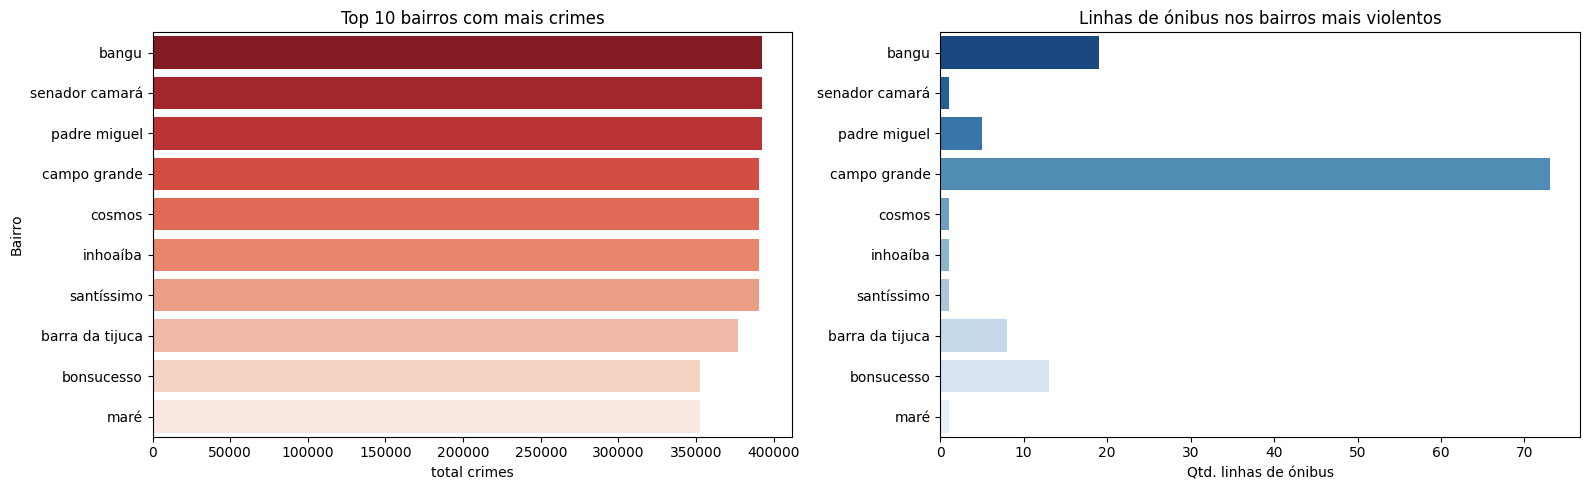

In [ ]:
# 5. Merge final e gráficos

df_final = pd.merge(
    linhas_bairro,
    crimes_bairro,
    left_on='ID_Bairro',
    right_on='bairro_norm',
    how='inner'
)

print(f"\nLinhas no df_final: {df_final.shape[0]}")
display(df_final.head())

# Gráfico 1: Top 10 bairros com mais crimes
top_crimes = df_final.sort_values('total crime', ascending=False).head(10)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.barplot(ax=axes[0], x='total crime', y='ID_Bairro', data=top_crimes, palette='Reds_r')
axes[0].set_title('Top 10 bairros com mais crimes')
axes[0].set_xlabel('total crimes')
axes[0].set_ylabel('Bairro')

# Gráfico 2: Quantidade de linhas nesses mesmos bairros
sns.barplot(ax=axes[1], x='qtd_linhas', y='ID_Bairro', data=top_crimes, palette='Blues_r')
axes[1].set_title('Linhas de ónibus nos bairros mais violentos')
axes[1].set_xlabel('Qtd. linhas de ónibus')
axes[1].set_ylabel('')

plt.tight_layout()
plt.show()

## Juntar ao df_final atributos populacionais (população, área e densidade)

In [ ]:
print(df_final.columns)

Index(['ID_Bairro', 'qtd_linhas', 'bairro_norm', 'total crime'], dtype='object')


In [ ]:
df_final

,ID_Bairro,qtd_linhas,bairro_norm,total crime
0,abolição,2,abolição,168404.0
1,acari,2,acari,275183.0
2,anchieta,2,anchieta,150231.0
3,andaraí,1,andaraí,197469.0
4,bancários,10,bancários,176404.0
...,...,...,...,...
69,taquara,18,taquara,298551.0
70,urca,5,urca,239446.0
71,vargem grande,3,vargem grande,140485.0
72,vicente de carvalho,4,vicente de carvalho,307304.0


In [ ]:
print(df_pop.columns)

Index(['Bairro', 'Total populacao', 'Homens', 'Mulheres'], dtype='object')


In [ ]:
df_area_pop['bairro_norm'] = df_area_pop['Bairro_x'].str.strip().str.lower()
df_final['bairro_norm'] = df_final['ID_Bairro'].str.strip().str.lower()

In [ ]:
df_final = pd.merge(
    df_final,
    df_area_pop,
    on='bairro_norm',
    how='left'
)

In [ ]:
set(df_final['bairro_norm']) - set(df_area_pop['bairro_norm'])

{'acari',
 'anchieta',
 'bancários',
 'barra de guaratiba',
 'coelho neto',
 'cordovil',
 'engenheiro leal',
 'engenho da rainha',
 'freguesia',
 'galeão',
 'gardênia azul',
 'honório gurgel',
 'jacaré',
 'jardim américa',
 'leme',
 'lins de vasconcelos',
 'marechal hermes',
 'maré',
 'padre miguel',
 'pavuna',
 'pechincha',
 'praça seca',
 'ribeira',
 'rocha',
 'são cristóvão',
 'vila valqueire'}

In [ ]:
print(df_final.columns)
display(df_final.head())

Index(['ID_Bairro', 'qtd_linhas', 'bairro_norm', 'total crime', 'OBJECTID_1',
       'OBJECTID', 'Área', 'NOME', 'REGIAO_ADM', 'AREA_PLANE', 'CODBAIRRO',
       'CODRA', 'CODBNUM', 'LINK', 'RP', 'Cod_RP', 'CODBAIRRO_', 'SHAPE_STAr',
       'SHAPE_STLe', 'Pop', 'Dens_Pop', 'De_PopKm', 'Shape__Area',
       'Shape__Length', 'Bairro_x', 'Total populacao', 'Homens', 'Mulheres',
       'Bairro_y', 'Zona', 'Densidade'],
      dtype='object')


,ID_Bairro,qtd_linhas,bairro_norm,total crime,OBJECTID_1,OBJECTID,Área,NOME,REGIAO_ADM,AREA_PLANE,...,De_PopKm,Shape__Area,Shape__Length,Bairro_x,Total populacao,Homens,Mulheres,Bairro_y,Zona,Densidade
0,abolição,2,abolição,168404.0,78.0,404.0,6.163327e+05,abolição,MEIER,3,...,18425.0,0.616333,4930.770122,abolição,11356,5046,6310,abolição,Zona Norte,18425.114916
1,acari,2,acari,275183.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,anchieta,2,anchieta,150231.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,andaraí,1,andaraí,197469.0,120.0,446.0,2.261300e+06,andaraí,VILA ISABEL,2,...,17408.0,2.261300,9938.098947,andaraí,39365,17370,21995,andaraí,Zona Norte,17408.124294
4,bancários,10,bancários,176404.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN


In [ ]:
df_final


,ID_Bairro,qtd_linhas,bairro_norm,total crime,OBJECTID_1,OBJECTID,Área,NOME,REGIAO_ADM,AREA_PLANE,...,De_PopKm,Shape__Area,Shape__Length,Bairro_x,Total populacao,Homens,Mulheres,Bairro_y,Zona,Densidade
0,abolição,2,abolição,168404.0,78.0,404.0,6.163327e+05,abolição,MEIER,3,...,18425.0,0.616333,4930.770122,abolição,11356,5046,6310,abolição,Zona Norte,18425.114916
1,acari,2,acari,275183.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2,anchieta,2,anchieta,150231.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
3,andaraí,1,andaraí,197469.0,120.0,446.0,2.261300e+06,andaraí,VILA ISABEL,2,...,17408.0,2.261300,9938.098947,andaraí,39365,17370,21995,andaraí,Zona Norte,17408.124294
4,bancários,10,bancários,176404.0,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
69,taquara,18,taquara,298551.0,104.0,430.0,1.320663e+07,taquara,JACAREPAGUA,4,...,7733.0,13.206630,22254.660387,taquara,102126,47522,54604,taquara,Zona Oeste,7732.934074
70,urca,5,urca,239446.0,130.0,456.0,2.319002e+06,urca,BOTAFOGO,2,...,3045.0,2.319002,14138.505263,urca,7061,3327,3734,urca,Zona Sul,3044.844526
71,vargem grande,3,vargem grande,140485.0,125.0,451.0,3.938038e+07,vargem grande,BARRA DA TIJUCA,4,...,356.0,39.380383,33697.276337,vargem grande,14039,6899,7140,vargem grande,Zona Oeste,356.497299
72,vicente de carvalho,4,vicente de carvalho,307304.0,47.0,373.0,1.835711e+06,vicente de carvalho,IRAJA,3,...,13599.0,1.835711,6753.007527,vicente de carvalho,24964,11625,13339,vicente de carvalho,Zona Norte,13599.093079


In [ ]:
df_final['crime_per_capita'] = df_final['total crime'] / df_area_pop['Total populacao']

In [ ]:
corr = df_final[['qtd_linhas', 'total crime', 'Densidade', 'crime_per_capita', 'Total populacao', 'Shape__Area']].corr()
corr

,qtd_linhas,total crime,Densidade,crime_per_capita,Total populacao,Shape__Area
qtd_linhas,1.000000,0.253734,-0.194159,0.278121,0.638782,0.496923
total crime,0.253734,1.000000,-0.074993,0.142964,0.308602,-0.062231
Densidade,-0.194159,-0.074993,1.000000,-0.002751,-0.139343,-0.381643
crime_per_capita,0.278121,0.142964,-0.002751,1.000000,0.095757,-0.059169
Total populacao,0.638782,0.308602,-0.139343,0.095757,1.000000,0.700913
Shape__Area,0.496923,-0.062231,-0.381643,-0.059169,0.700913,1.000000


In [ ]:
fig = px.scatter(df_final,x='Densidade',y='total crime',color='Zona')
fig.update_traces(marker=dict(size=12))
fig.update_layout(width=800, height=500)
fig.show()

# Observação de Lucas : Gráfico ficou perfeito! E demonstra de forma lindissima o total de crimes para cada bairro com sua respectiva densidade

In [ ]:
df_Densidade_Crimes = df_final[['Total populacao','total crime']]
corrDC = df_Densidade_Crimes.corr()
corrDC

# correlação igual a 0,326 quer dizer ser pequena

,Total populacao,total crime
Total populacao,1.000000,0.308602
total crime,0.308602,1.000000


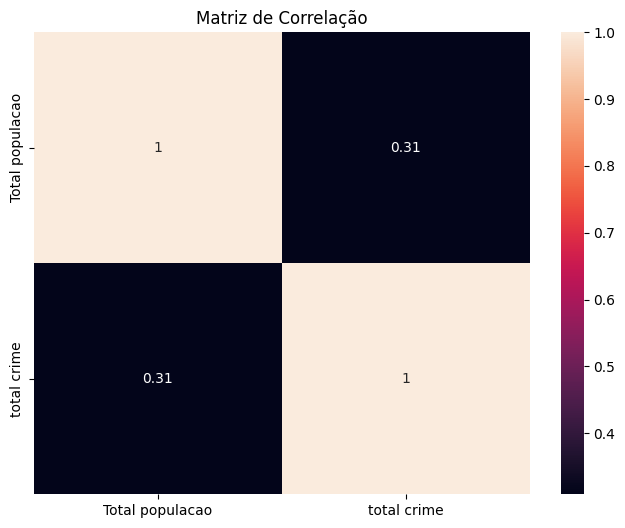

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corrDC, annot=True)

plt.title('Matriz de Correlação')
plt.show()

# Baixa correlação entre essas duas variáveis

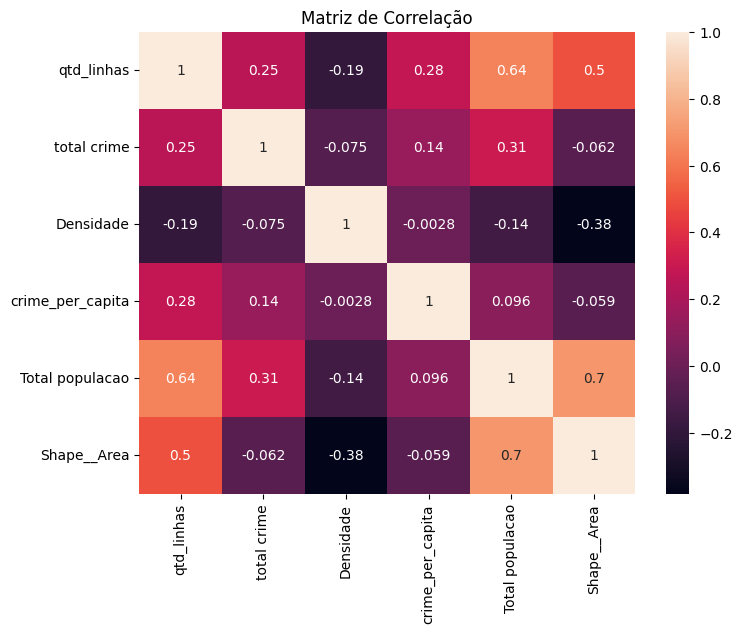

In [ ]:
plt.figure(figsize=(8,6))
sns.heatmap(corr, annot=True)

plt.title('Matriz de Correlação')
plt.show()

# Total de população e quantidade de linhas estão bem correlacionados

In [ ]:
df_final.columns

Index(['ID_Bairro', 'qtd_linhas', 'bairro_norm', 'total crime', 'OBJECTID_1',
       'OBJECTID', 'Área', 'NOME', 'REGIAO_ADM', 'AREA_PLANE', 'CODBAIRRO',
       'CODRA', 'CODBNUM', 'LINK', 'RP', 'Cod_RP', 'CODBAIRRO_', 'SHAPE_STAr',
       'SHAPE_STLe', 'Pop', 'Dens_Pop', 'De_PopKm', 'Shape__Area',
       'Shape__Length', 'Bairro_x', 'Total populacao', 'Homens', 'Mulheres',
       'Bairro_y', 'Zona', 'Densidade', 'crime_per_capita'],
      dtype='object')

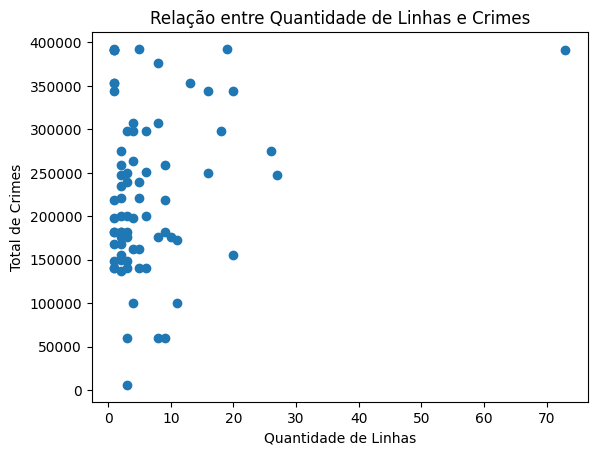

In [ ]:
# Scatter da quantidade de linhas sobre os crimes totais
plt.scatter(x='qtd_linhas', y='total crime', data = df_final)
plt.xlabel('Quantidade de Linhas')
plt.ylabel('Total de Crimes')
plt.title('Relação entre Quantidade de Linhas e Crimes')
plt.show()

In [ ]:
# Novo df para abrigar apenas essas colunas
df_final_valores = df_final[['qtd_linhas', 'total crime']]

In [ ]:
# Vendo ordem decrescente na qtd_linhas
df_final_valores.sort_values('qtd_linhas', ascending=False)

,qtd_linhas,total crime
12,73,390720.0
22,27,247469.0
48,26,275183.0
42,20,343790.0
63,20,155510.0
...,...,...
49,1,140976.0
55,1,352849.0
52,1,168404.0
65,1,392394.0


In [ ]:
# Calculando a correlação :
correlacao = df_final_valores.corr()

In [ ]:
# Histograma da quantidade de linhas de ônibus
hist = px.histogram(df_final['qtd_linhas'], nbins=20, height=800)
hist.show()

In [ ]:
# Histograma do total de crimes
hist = px.histogram(df_final['total crime'], nbins=20, height=800)
hist.show()

<Axes: >

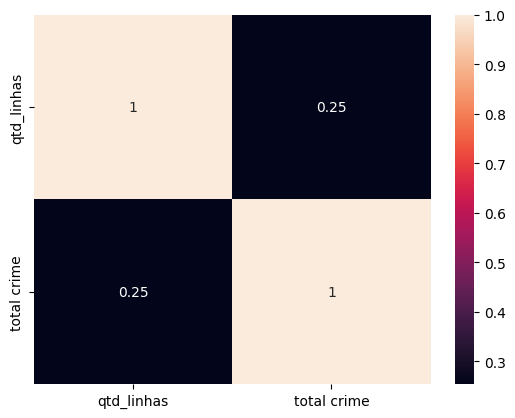

In [ ]:
# Vendo o valor da correlação (usando heatmap) :
sns.heatmap(correlacao, annot=True)
# Vemos que a correlação entre total de crimes e linhas é fraco (achamos com outros metodos entre 0,25 e 0,33)

# **Análises de Correlação Cruzada**


In [ ]:
# 1. Preparação dos dados de População (df_area)
df_area_clean = df_area[['NOME', 'Shape__Area']].copy()
df_area_clean['NOME'] = df_area_clean['NOME'].str.strip().str.lower()

# 2. Preparação de Paradas por Bairro
paradas_bairro = df_merged.explode('ID_Bairro').groupby('ID_Bairro')['stop_id'].nunique().reset_index()
paradas_bairro.columns = ['ID_Bairro', 'qtd_paradas']

# 3. Consolidação Final
# Removemos colunas duplicadas de df_final antes do merge para evitar sufixos _x e _y
if 'Shape__Area' in df_final.columns:
    df_final_clean = df_final.drop(columns=['Shape__Area'])
else:
    df_final_clean = df_final.copy()

df_master = pd.merge(df_final_clean, df_area_clean, left_on='ID_Bairro', right_on='NOME', how='inner')
df_master = pd.merge(df_master, paradas_bairro, on='ID_Bairro', how='left').fillna(0)

# Exibir correlações numéricas
display(df_master[['total crime', 'Shape__Area', 'qtd_linhas', 'qtd_paradas']].corr())

# Quantidade de linhas de onibus e quantidade de paradas são MUITO correlacionados!

/tmp/ipykernel_8935/2311440892.py:17: FutureWarning:

Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`



,total crime,Shape__Area,qtd_linhas,qtd_paradas
total crime,1.000000,-0.038935,0.251654,0.274030
Shape__Area,-0.038935,1.000000,0.486787,0.429887
qtd_linhas,0.251654,0.486787,1.000000,0.896322
qtd_paradas,0.274030,0.429887,0.896322,1.000000


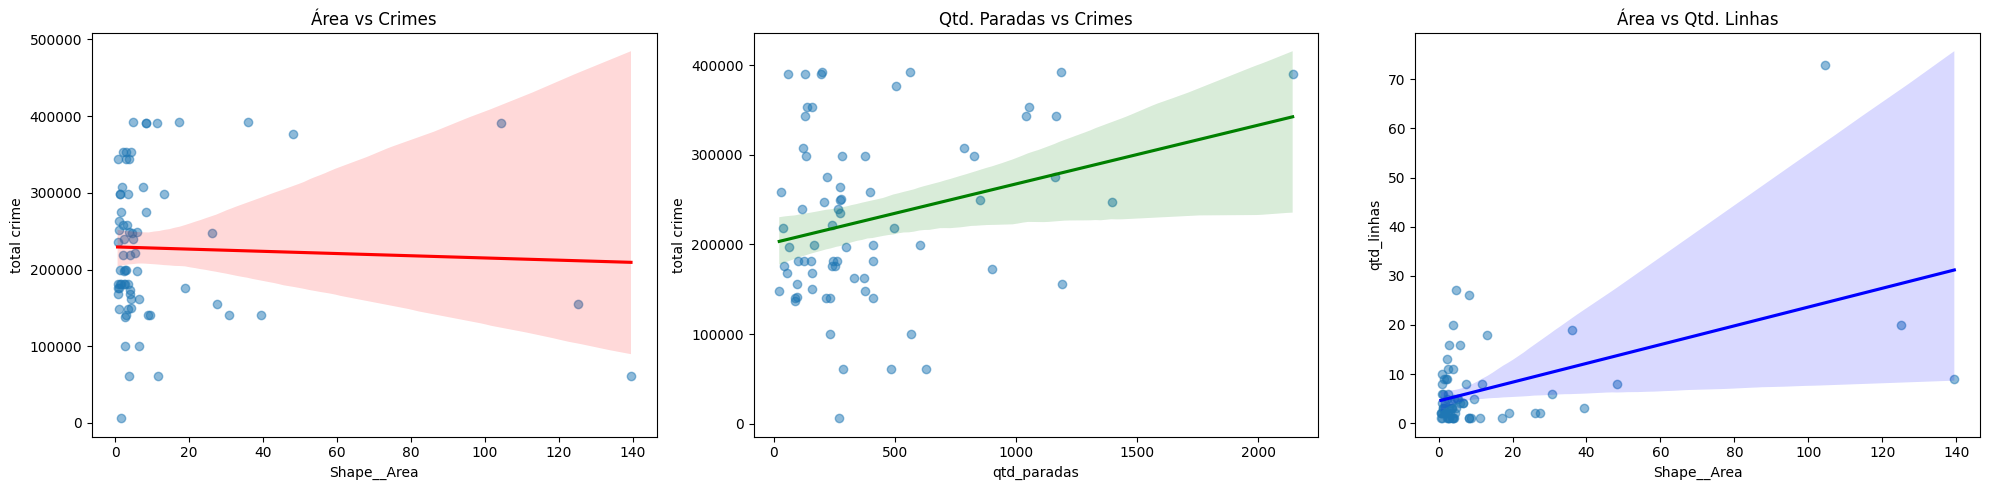

In [ ]:
# Visualizações de Correlação
fig, axes = plt.subplots(1, 3, figsize=(20, 5))

# Densidade da População X Crimes
sns.regplot(ax=axes[0], x='Shape__Area', y='total crime', data=df_master, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
axes[0].set_title('Área vs Crimes')

# Número de Paradas X Crimes
sns.regplot(ax=axes[1], x='qtd_paradas', y='total crime', data=df_master, scatter_kws={'alpha':0.5}, line_kws={'color':'green'})
axes[1].set_title('Qtd. Paradas vs Crimes')

# Quantidade de Linhas X Densidade Populacional
sns.regplot(ax=axes[2], x='Shape__Area', y='qtd_linhas', data=df_master, scatter_kws={'alpha':0.5}, line_kws={'color':'blue'})
axes[2].set_title('Área vs Qtd. Linhas')

plt.tight_layout()
plt.show()

## **Análise de Correlação por Gênero e Crimes**
Nesta seção, exploramos como as populações masculina e feminina se relacionam com os índices de criminalidade nos bairros.

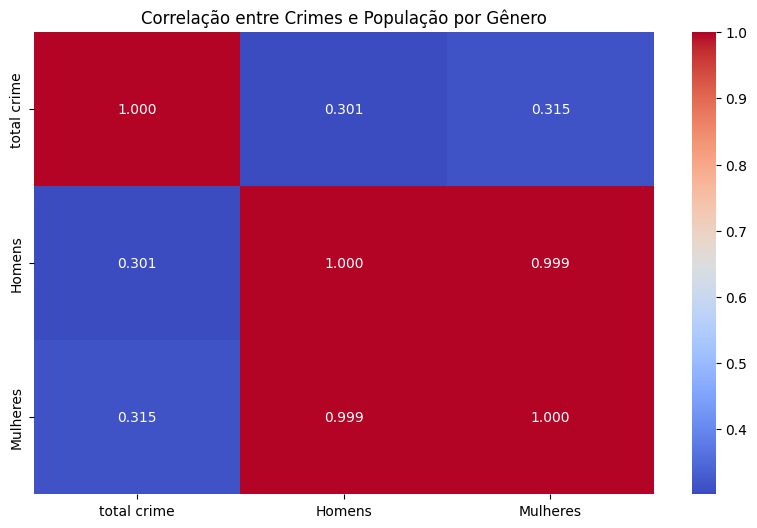

In [ ]:
# 1. Matriz de Correlação: Total Crime, Homens e Mulheres
corr_genero = df_final[['total crime', 'Homens', 'Mulheres']].corr()

plt.figure(figsize=(10, 6))
sns.heatmap(corr_genero, annot=True, cmap='coolwarm', fmt='.3f')
plt.title('Correlação entre Crimes e População por Gênero')
plt.show()

# Achei que haveria uma melhor correlação entre os crimes e a quantidade de pessoas, todavia, foi baixa a correlação

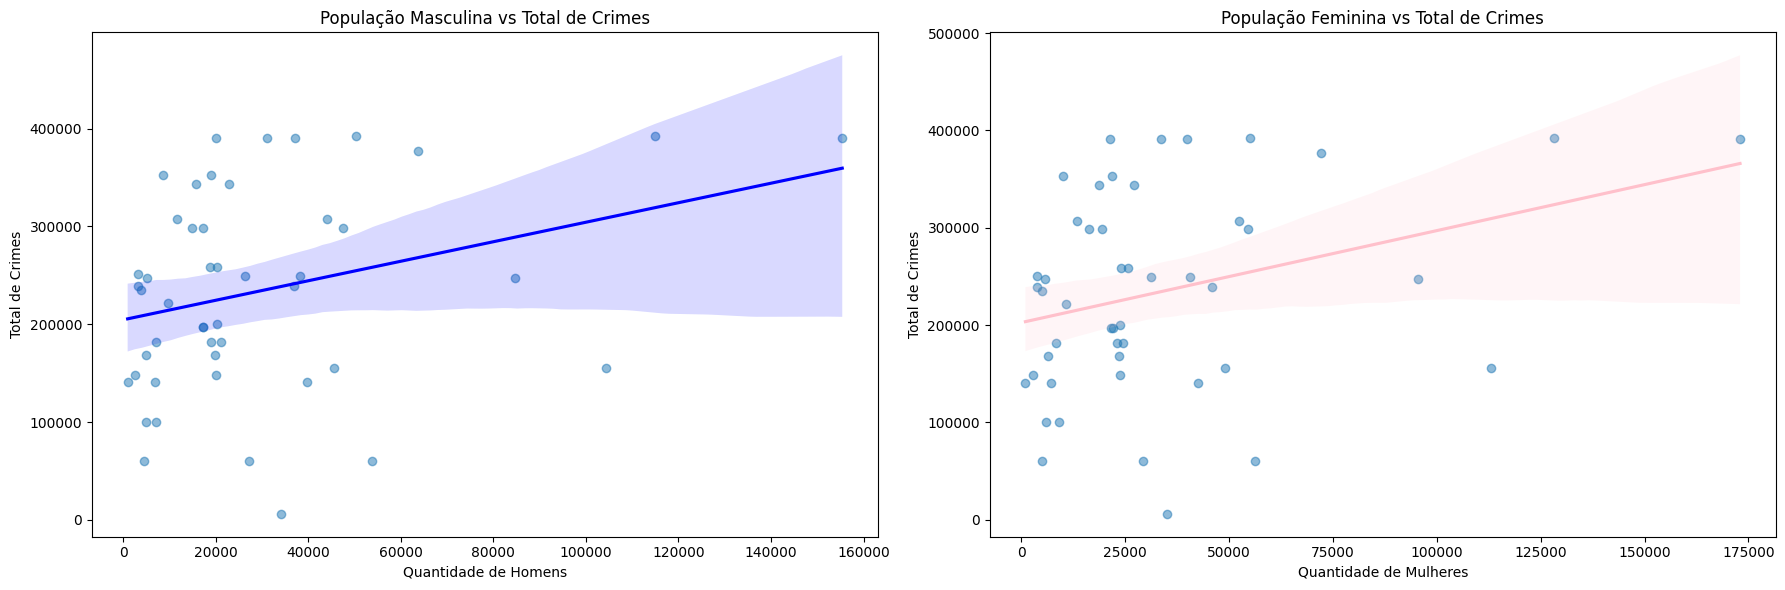

In [ ]:
# 2. Gráficos de Regressão: Relação entre Gênero e Crescimento de Crimes
# Garantindo que os dados sejam numéricos e removendo NaNs para evitar erros no regplot
df_plot = df_final[['Homens', 'Mulheres', 'total crime']].apply(pd.to_numeric, errors='coerce').dropna()

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# Homens vs Total Crime
sns.regplot(ax=axes[0], x='Homens', y='total crime', data=df_plot,
            scatter_kws={'alpha':0.5}, line_kws={'color':'blue'})
axes[0].set_title('População Masculina vs Total de Crimes')
axes[0].set_xlabel('Quantidade de Homens')
axes[0].set_ylabel('Total de Crimes')

# Mulheres vs Total Crime
sns.regplot(ax=axes[1], x='Mulheres', y='total crime', data=df_plot,
            scatter_kws={'alpha':0.5}, line_kws={'color':'pink'})
axes[1].set_title('População Feminina vs Total de Crimes')
axes[1].set_xlabel('Quantidade de Mulheres')
axes[1].set_ylabel('Total de Crimes')

plt.tight_layout()
plt.show()

### **Novas Ideias de Correlação e Modelagem Estatística**
Nesta parte, expandimos a análise para incluir tentar incluir mais : **Correlações Geográficas** (Relação entre a densidade de paradas e crimes por km²) e as **Modelagem Probabilística** (Tratamento de `qtd_linhas` como distribuição de Poisson e `total crime` como Normal)

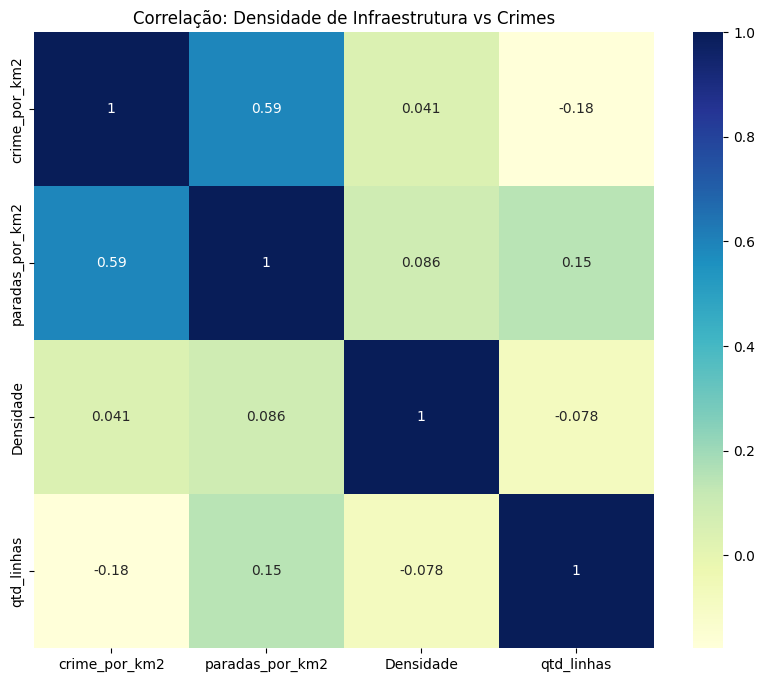

In [ ]:
import statsmodels.api as sm
import statsmodels.formula.api as smf
from scipy.stats import poisson, norm

# Nova Correlação: Normalizando por Área
# Vamos ver se bairros menores mas com muitos crimes/paradas mostram padrões diferentes
df_master['crime_por_km2'] = df_master['total crime'] / df_master['Shape__Area']
df_master['paradas_por_km2'] = df_master['qtd_paradas'] / df_master['Shape__Area']

corr_geo = df_master[['crime_por_km2', 'paradas_por_km2', 'Densidade', 'qtd_linhas']].corr()

plt.figure(figsize=(10, 8))
sns.heatmap(corr_geo, annot=True, cmap='YlGnBu')
plt.title('Correlação: Densidade de Infraestrutura vs Crimes')
plt.show()

#### **Modelagem de Poisson (Variável de Contagem: qtd_linhas)**
Calcularemos o $\lambda$ (média) da distribuição de Poisson para as linhas de ônibus e visualizaremos a probabilidade.

Lambda (média) das linhas de ônibus: 6.76


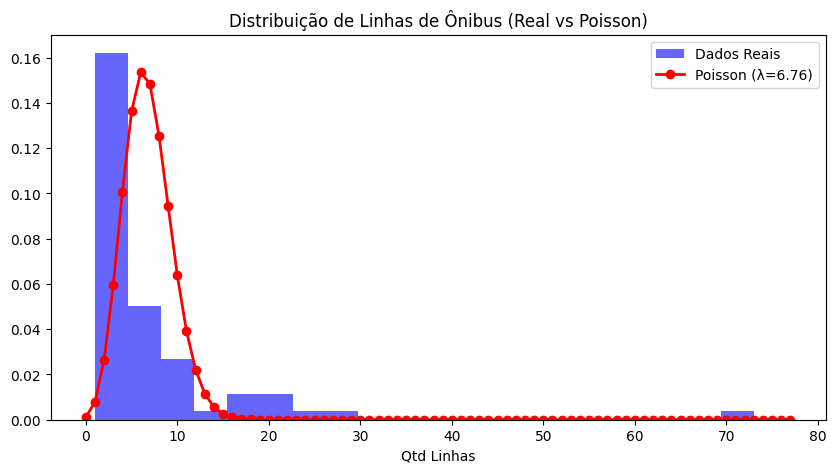

In [ ]:
# Cálculo do Lambda para Poisson
lam = df_master['qtd_linhas'].mean()
print(f"Lambda (média) das linhas de ônibus: {lam:.2f}")

# Visualização da Distribuição Teórica vs Real
x_plot = np.arange(0, df_master['qtd_linhas'].max() + 5)
plt.figure(figsize=(10, 5))
plt.hist(df_master['qtd_linhas'], bins=20, density=True, alpha=0.6, color='blue', label='Dados Reais')
plt.plot(x_plot, poisson.pmf(x_plot, lam), 'ro-', lw=2, label=f'Poisson (λ={lam:.2f})')
plt.title('Distribuição de Linhas de Ônibus (Real vs Poisson)')
plt.xlabel('Qtd Linhas')
plt.legend()
plt.show()

# também vi a parte de a quantidade de assaltos parecer uma variável aleatória contínua Normal

### **Síntese de Análise: Dispersão e Heatmap de Variáveis Chave**
Nesta etapa final, consolidamos o entendimento sobre como o volume de crimes se comporta em relação à infraestrutura urbana (paradas e linhas de transporte público) junto da densidade populacional, vendo em áreas urbanas e rurais

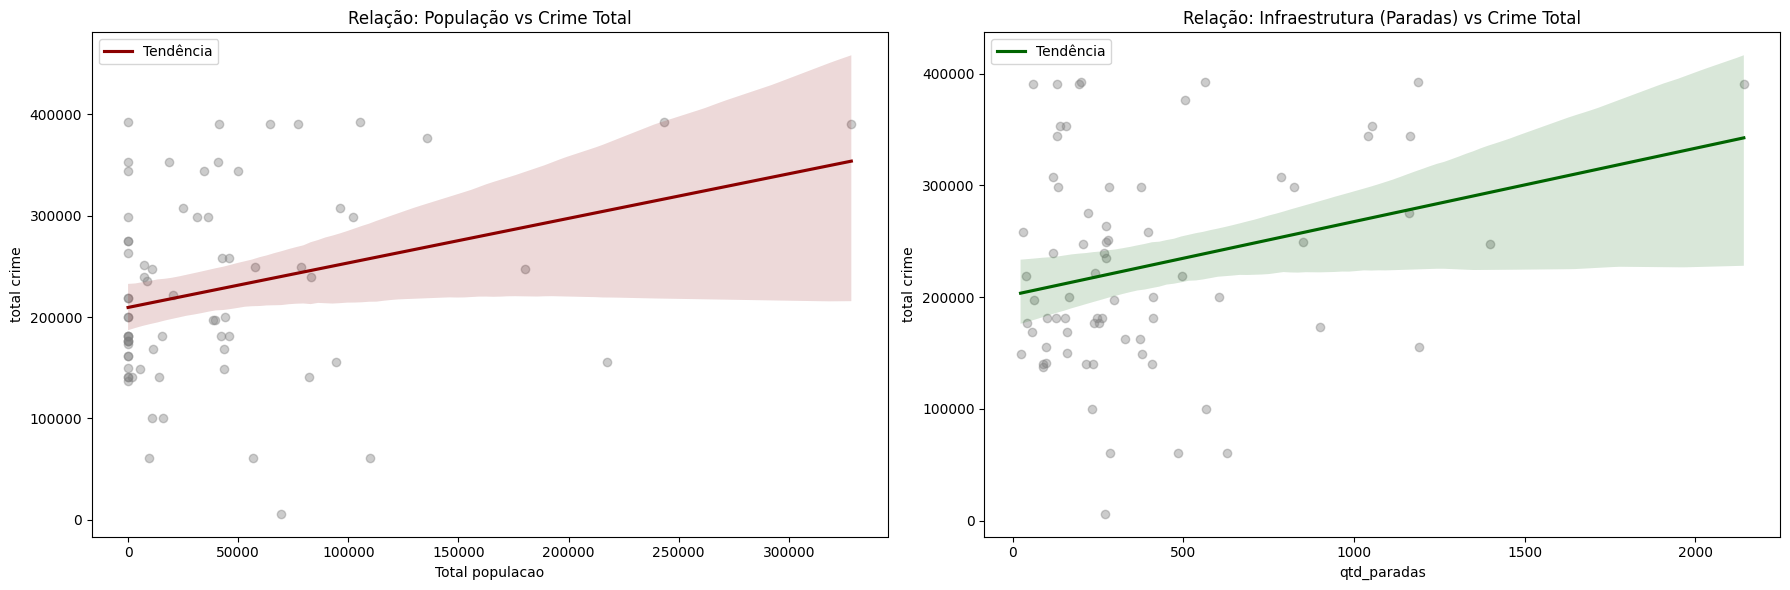

In [ ]:
# Gráficos de Dispersão com Linha de Tendência (Regressão Linear)
fig, axes = plt.subplots(1, 2, figsize=(18, 6))

# População Total vs Total de Crimes
sns.regplot(ax=axes[0], x='Total populacao', y='total crime', data=df_master,
            scatter_kws={'alpha':0.4, 'color':'gray'}, line_kws={'color':'darkred', 'label':'Tendência'})
axes[0].set_title('Relação: População vs Crime Total')
axes[0].legend()

# Qtd de Paradas vs Total de Crimes
sns.regplot(ax=axes[1], x='qtd_paradas', y='total crime', data=df_master,
            scatter_kws={'alpha':0.4, 'color':'gray'}, line_kws={'color':'darkgreen', 'label':'Tendência'})
axes[1].set_title('Relação: Infraestrutura (Paradas) vs Crime Total')
axes[1].legend()

plt.tight_layout()
plt.show()

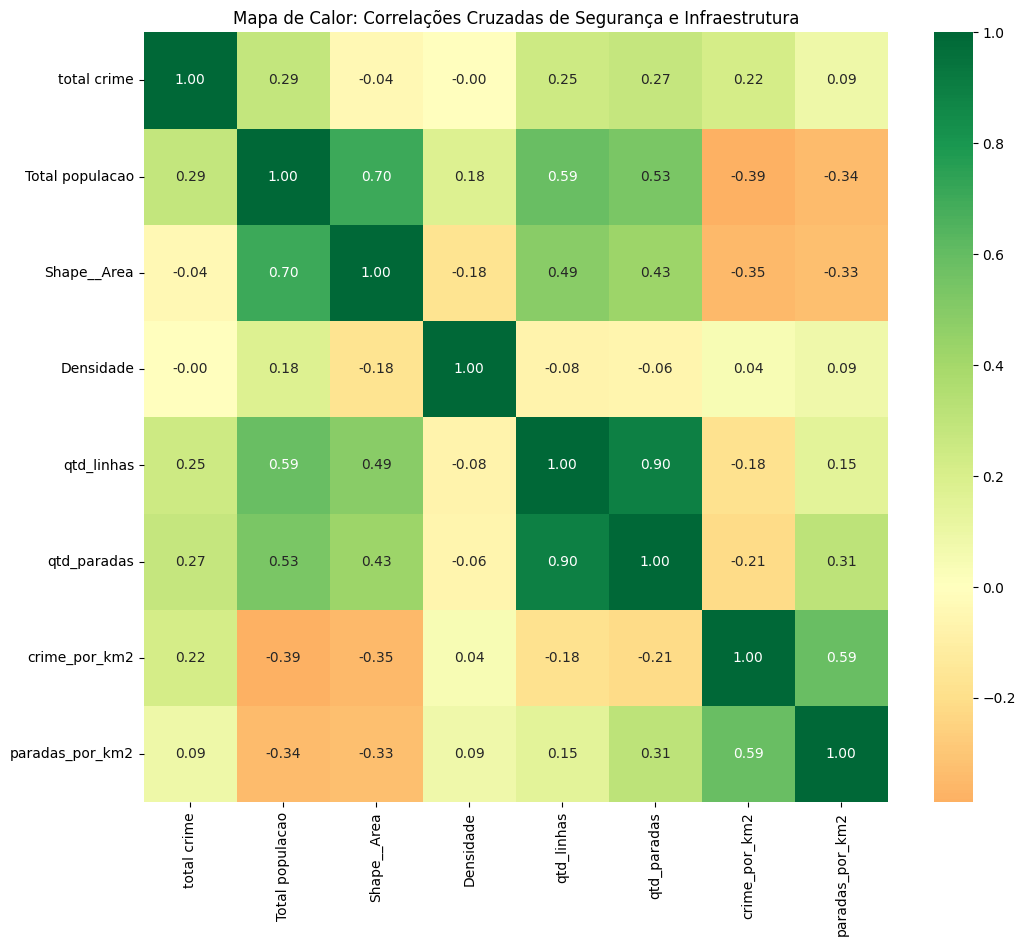

In [ ]:
# Heatmap de Correlação Consolidado
# Selecionando apenas as colunas métricas para o heatmap final
metrias_final = df_master[['total crime', 'Total populacao', 'Shape__Area', 'Densidade', 'qtd_linhas', 'qtd_paradas', 'crime_por_km2', 'paradas_por_km2']]
corr_final = metrias_final.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_final, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Mapa de Calor: Correlações Cruzadas de Segurança e Infraestrutura')
plt.show()

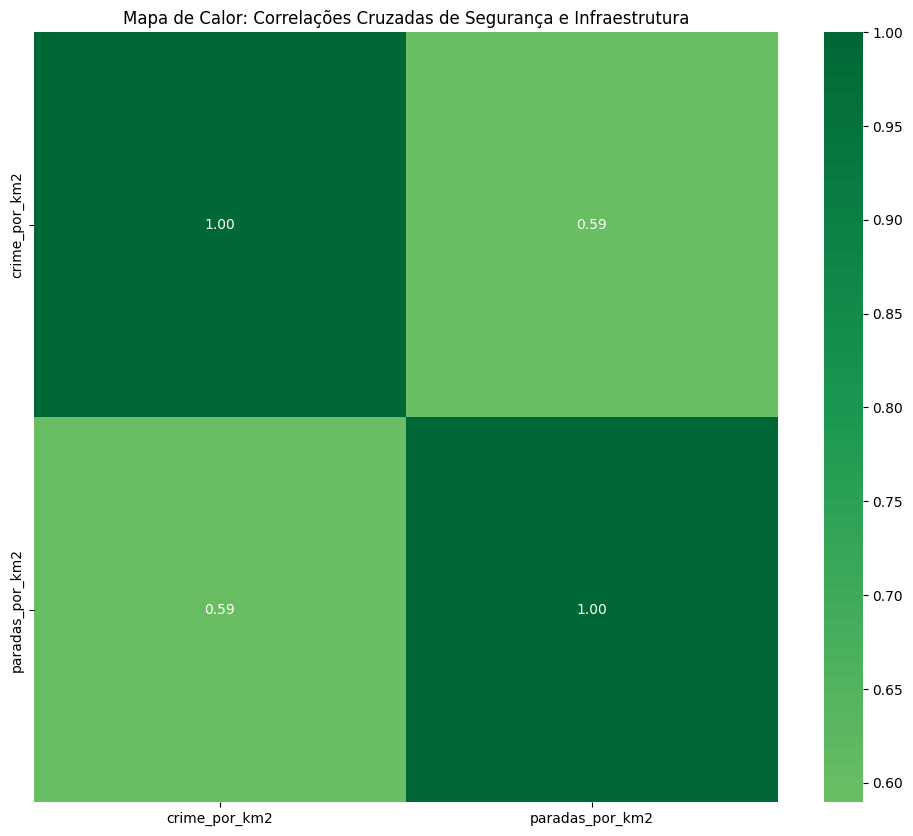

In [ ]:
metrias_final = df_master[['crime_por_km2', 'paradas_por_km2']]
corr_final = metrias_final.corr()

plt.figure(figsize=(12, 10))
sns.heatmap(corr_final, annot=True, cmap='RdYlGn', center=0, fmt='.2f')
plt.title('Mapa de Calor: Correlações Cruzadas de Segurança e Infraestrutura')
plt.show()

In [ ]:
# Modelo XGBoost Regressor para Previsão de Roubos

from sklearn.metrics import mean_absolute_error, mean_absolute_percentage_error, r2_score

# 1. Carregamento e Limpeza Inicial dos Dados
# ==========================================
# Carrega o DataFrame original de roubos e prepara a coluna alvo.

df_ML = df_roubos1.copy() # Cria uma cópia do DataFrame original para evitar modificar os dados brutos.

# Garante que a coluna alvo 'roubos' exista somando todas as categorias de roubo.
# Filtra colunas que contêm 'roubo' no nome (case-insensitive) e que não são 'total_roubos'.
colunas_roubo = [col for col in df_ML.columns if 'roubo' in col.lower() and 'total' not in col.lower()]
df_ML['roubos'] = df_ML[colunas_roubo].sum(axis=1) # Soma as contagens de todas as subcategorias de roubo para criar a variável alvo.

# Remove a coluna 'Unnamed: 0' se existir, que geralmente é um índice gerado automaticamente ao salvar/carregar CSVs/Excel.
if 'Unnamed: 0' in df_ML.columns:
    df_ML = df_ML.drop(columns=['Unnamed: 0'])

# 2. Codificação da Variável Categórica 'CISP'
# ==========================================
# Transforma a identificação textual do CISP em um formato numérico para o modelo.

df_ML['cisp'] = df_ML['cisp'].astype(str) # Garante que a coluna 'cisp' seja tratada como string.
le = LabelEncoder() # Inicializa o LabelEncoder.
df_ML['cisp_codificado'] = le.fit_transform(df_ML['cisp']) # Codifica cada identificador CISP único com um número inteiro.

# ==========================================
# 3. FEATURE ENGINEERING: Criação de Lags e Média Móvel
# ==========================================
# Gera variáveis temporais que capturam o histórico de roubos para cada CISP,
# essenciais para modelos de séries temporais.

# Passo A: Ordena o DataFrame para garantir o cálculo correto dos lags.
# A ordenação por CISP, ano e mês é crucial para que as operações 'shift' e 'rolling'
# funcionem corretamente dentro de cada grupo (CISP) e na sequência temporal.
df_ML = df_ML.sort_values(by=['cisp', 'ano', 'mes'])

# Passo B: Cria as features de lag e média móvel.
# 'lag_1': Roubos do mês anterior. Representa a inércia imediata.
df_ML['lag_1'] = df_ML.groupby('cisp')['roubos'].shift(1)
# 'lag_12': Roubos do mesmo mês no ano anterior. Captura a sazonalidade anual.
df_ML['lag_12'] = df_ML.groupby('cisp')['roubos'].shift(12)

# 'media_3m': Média móvel dos roubos dos últimos 3 meses (excluindo o mês atual).
# O '.shift(1)' é importante para evitar "data leakage", pois garante que a média
# não inclua a informação do mês que estamos tentando prever.
df_ML['media_3m'] = df_ML.groupby('cisp')['roubos'].transform(lambda x: x.rolling(window=3).mean().shift(1))

# Passo C: Limpeza de nulos e zeros após a criação de features.
# Remove linhas que não possuem dados históricos completos para os lags/médias móveis.
# Isso é comum, pois os primeiros meses (e anos para lag_12) não terão valores de lag.
df_ML = df_ML.dropna(subset=['lag_1', 'media_3m', 'lag_12'])
# Remove linhas onde a contagem de roubos é zero. Isso pode ser uma decisão de modelagem
# para focar apenas em períodos com ocorrências de roubo, ou pode ser ajustado
# dependendo da meta de previsão (prever 0s também).
df_ML = df_ML[df_ML['roubos'] > 0]

# ==========================================
# 4. PREPARAÇÃO PARA O TREINAMENTO DO MODELO
# ==========================================
# Define as variáveis preditoras (features) e a variável alvo (y), e divide os dados em conjuntos de treino e teste.

# Ordena cronologicamente novamente antes da divisão para garantir uma divisão temporal correta.
# Isso é crucial para simular um cenário de previsão real, onde o modelo é treinado em dados
# passados e avaliado em dados futuros.
df_ML = df_ML.sort_values(by=['ano', 'mes'])

# Atualiza a lista de colunas preditoras a serem usadas no modelo.
features = ['cisp_codificado', 'mes', 'ano', 'lag_1', 'media_3m', 'lag_12']
X = df_ML[features] # Variáveis independentes (preditoras).
y = df_ML['roubos'] # Variável dependente (alvo).

# Divisão Temporal (80% treino, 20% teste).
# `shuffle=False` é essencial para dados de séries temporais, mantendo a ordem cronológica.
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, shuffle=False)

# ==========================================
# 5. TRANSFORMAÇÃO LOGARÍTMICA E TREINO DO MODELO
# ==========================================
# Aplica uma transformação logarítmica à variável alvo e treina o modelo XGBoost.

# Aplica a transformação logarítmica (log1p = log(1+x)) à variável alvo do conjunto de treino.
# Isso ajuda a estabilizar a variância e tornar a distribuição mais normal, o que é benéfico
# para muitos modelos de regressão, especialmente com dados de contagem que são frequentemente assimétricos.
y_train_log = np.log1p(y_train)

# Configura e inicializa o modelo XGBoost Regressor.
# n_estimators: número de árvores.
# learning_rate: taxa de aprendizado, controla o tamanho do passo em cada iteração.
# max_depth: profundidade máxima de cada árvore, controla a complexidade do modelo.
# random_state: para reprodutibilidade dos resultados.
modelo = XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=5,
    random_state=42
)
modelo.fit(X_train, y_train_log) # Treina o modelo com os dados de treino transformados.

# ==========================================
# 6. PREVISÃO E REVERSÃO DA ESCALA ORIGINAL
# ==========================================
# Realiza previsões no conjunto de teste e reverte a transformação logarítmica.

previsoes_log = modelo.predict(X_test) # Realiza previsões no conjunto de teste (ainda na escala logarítmica).
# Reverte a transformação logarítmica para obter as previsões na escala original (expm1 = exp(x)-1).
previsoes_finais = np.expm1(previsoes_log)

# Previsão

--- Resultado Final ---
MAE: 35.22 roubos
MAPE: 20.98%
R² Score: 0.7999 (79.99%)


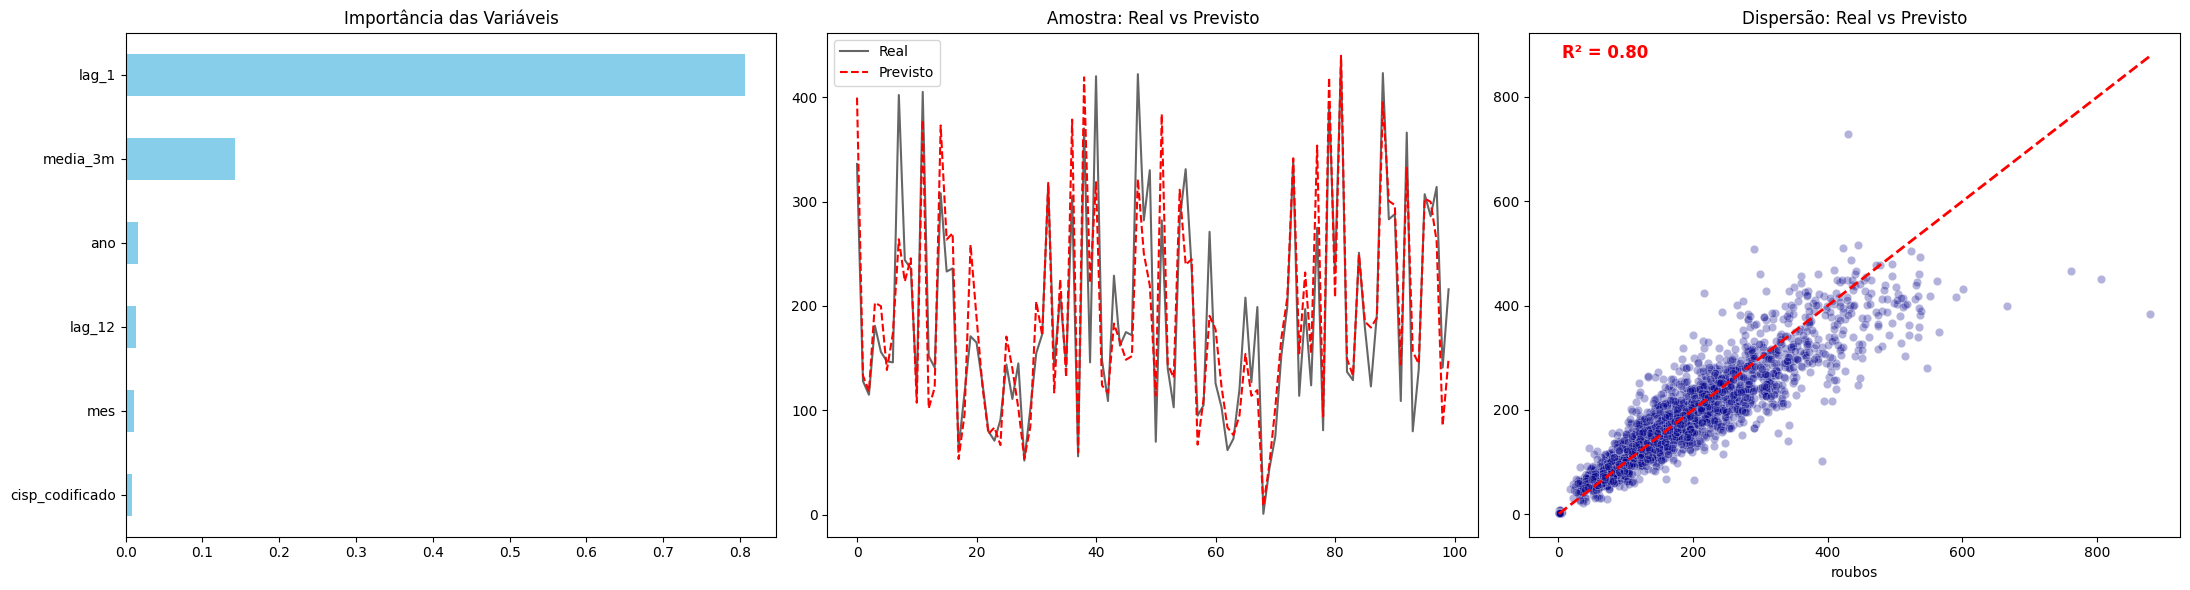

In [ ]:
# 7. Avaliação Final do Modelo
# ============================
# Calcula métricas de desempenho para avaliar a qualidade das previsões.

mae = mean_absolute_error(y_test, previsoes_finais) # Erro Médio Absoluto.
mape = mean_absolute_percentage_error(y_test, previsoes_finais) * 100 # Erro Percentual Médio Absoluto.
r2 = r2_score(y_test, previsoes_finais) # Coeficiente de Determinação (R²).

print(f"--- Resultado Final ---")
print(f"MAE: {mae:.2f} roubos") # Apresenta o MAE.
print(f"MAPE: {mape:.2f}%")   # Apresenta o MAPE.
print(f"R² Score: {r2:.4f} ({r2*100:.2f}%)") # Apresenta o R².

# ==========================================
# 8. VISUALIZAÇÃO DOS RESULTADOS
# ==========================================
# Gera gráficos para visualizar a importância das features, a comparação entre valores reais e previstos, e a dispersão.

fig, axes = plt.subplots(1, 3, figsize=(22, 6)) # Cria uma figura com 3 subplots.

# Gráfico 1: Importância das Var iáveis
# Mostra quais features foram mais relevantes para o modelo.
importancia = pd.Series(modelo.feature_importances_, index=features).sort_values() # Calcula e ordena a importância das features.
importancia.plot(kind='barh', ax=axes[0], color='skyblue') # Plota a importância como um gráfico de barras horizontais.
axes[0].set_title('Importância das Variáveis')

# Gráfico 2: Comparação Real vs Previsto (Amostra)
# Compara visualmente os primeiros 100 valores reais com os previstos.
axes[1].plot(y_test.values[:100], label='Real', color='black', alpha=0.6) # Valores reais.
axes[1].plot(previsoes_finais[:100], label='Previsto', color='red', linestyle='--') # Valores previstos.
axes[1].set_title('Amostra: Real vs Previsto')
axes[1].legend() # Adiciona a legenda.

# Gráfico 3: Dispersão: Real vs Previsto
# Avalia a relação geral entre os valores reais e previstos.
sns.scatterplot(ax=axes[2], x=y_test, y=previsoes_finais, alpha=0.3, color='darkblue') # Gráfico de dispersão.
# Adiciona uma linha diagonal (y=x) para representar a previsão perfeita.
axes[2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2)
# Adiciona o texto do R² no gráfico de dispersão para uma visualização rápida da qualidade do ajuste.
axes[2].text(0.05, 0.95, f'R² = {r2:.2f}', transform=axes[2].transAxes, fontsize=12, fontweight='bold', color='red')
axes[2].set_title('Dispersão: Real vs Previsto')

plt.tight_layout() # Ajusta o layout para evitar sobreposição de elementos.
plt.show() # Exibe os gráficos.

### **O que entendemos da análise:**

O planejamento urbano e a segurança pública parecem estar intrinsecamente ligados aos eixos de transporte. Bairros com maior densidade de paradas exigem estratégias de policiamento mais focadas devido ao fluxo de pessoas.